In [1]:
from resources.imports import *

from resources.lattices import Geometry, effProperties
from resources.MLdata import DATA, load_data, prep_UTdata, prep_FTdata, prep_MULTIdata, remove_outliers, split_data, \
                             save_MLdata, save_MULTIdata, plot_sampling, locSims, get_stats, plot_frequency, \
                             plot_properties, plot_curve

In [2]:
### Global Inputs

mode = ("compare", "Target-xs")

DAT = DATA(path=1, 
           path_add="",
           load=False,
           LAT="FCC", 
           dis="disNodes", 
           dN=0.2,
           mechMode="both")

if mode is not None:
    if mode[0].lower() == "compare":
        DATc = DATA(path=1, 
                    path_add=mode[1],
                    load=DAT.load,
                    LAT=DAT.LAT, 
                    dis=DAT.dis, 
                    dN=DAT.dN,
                    mechMode=DAT.mechMode)

if DAT.LAT.lower() == "fcc":
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "kagome":
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "hex":
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "tri":
    manual_outliersUT = None
    manual_outliersFT = None

c:\Users\exy053\OneDrive - Queen Mary, University of London\Documents\Research\p1-LatticeFractureToughness\p1git-Lattices\code\resources\lattices.py:637: RuntimeWarning: divide by zero encountered in double_scalars
  return np.array([np.cos(np.arctan([n0[1]/n0[0]]))[0], np.sin(np.arctan([n0[1]/n0[0]]))[0]])


# Load Data

In [3]:
if DAT.load is not True:
    if DAT.UTmechTest:
        DAT.UT_INcsv  = DAT.PATH + f'Ductile-{DAT.dis}-IN.csv'
        DAT.UT_OUTcsv = DAT.PATH + f'Ductile-{DAT.dis}-OUT.csv'
        DAT.UT_INcsv_f = None
        if DAT.freq:
            DAT.UT_INcsv_f = DAT.PATH + f'Ductile-{DAT.dis}-INf.csv'

    if DAT.FTmechTest:
        DAT.FT_INcsv  = DAT.PATH + f'Fracture-{DAT.dis}-IN.csv'
        DAT.FT_OUTcsv = DAT.PATH + f'Fracture-{DAT.dis}-OUT.csv'
        DAT.FT_INcsv_f = None
        if DAT.freq:
            DAT.FT_INcsv_f = DAT.PATH + f'Fracture-{DAT.dis}-INf.csv'

    if mode is not None and mode[0].lower() == "compare":
        if DATc.UTmechTest:
            DATc.UT_INcsv  = DATc.PATH + f'Ductile-{DATc.dis}-IN.csv'
            DATc.UT_OUTcsv = DATc.PATH + f'Ductile-{DATc.dis}-OUT.csv'
            DATc.UT_INcsv_f = None
            if DATc.freq:
                DATc.UT_INcsv_f = DATc.PATH + f'Ductile-{DATc.dis}-INf.csv'

        if DATc.FTmechTest:
            DATc.FT_INcsv  = DATc.PATH + f'Fracture-{DATc.dis}-IN.csv'
            DATc.FT_OUTcsv = DATc.PATH + f'Fracture-{DATc.dis}-OUT.csv'
            DATc.FT_INcsv_f = None
            if DATc.freq:
                DATc.FT_INcsv_f = DATc.PATH + f'Fracture-{DATc.dis}-INf.csv'

In [4]:
if DAT.load is not True:
    if DAT.UTmechTest:
        DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_INf_df, DAT.UT_perINr_df, DAT.UT_perIN_df, DAT.UT_perOUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df = load_data(DAT.UT_INcsv, DAT.UT_OUTcsv, DAT.UT_INcsv_f)

    if DAT.FTmechTest:
        DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_INf_df, DAT.FT_perINr_df, DAT.FT_perIN_df, DAT.FT_perOUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df = load_data(DAT.FT_INcsv, DAT.FT_OUTcsv, DAT.FT_INcsv_f)

    if mode is not None and mode[0].lower() == "compare":
        if DATc.UTmechTest:
            DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_INf_df, DATc.UT_perINr_df, DATc.UT_perIN_df, DATc.UT_perOUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df = load_data(DATc.UT_INcsv, DATc.UT_OUTcsv, DATc.UT_INcsv_f)

        if DATc.FTmechTest:
            DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_INf_df, DATc.FT_perINr_df, DATc.FT_perIN_df, DATc.FT_perOUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df = load_data(DATc.FT_INcsv, DATc.FT_OUTcsv, DATc.FT_INcsv_f)

# Geometry

In [5]:
if DAT.load is not True:
    DAT.geom.FTcalc()

# Prep Data

In [6]:
if DAT.load is not True:
    if DAT.UTmechTest:
        DAT.UT_dIN_r, DAT.UT_dOUT_r, DAT.UT_INf_r, DAT.UT_xOUT, DAT.UT_allProps_r, DAT.UT_allProps_r_df = prep_UTdata(DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_perOUT_df, DAT.UT_OUT_df, DAT.UT_INf_df)
        DAT.UT_dIN, DAT.UT_dOUT, DAT.UT_INf, DAT.UT_allProps, DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_allProps_df, DAT.UT_INf_df = remove_outliers(DAT.UT_dIN_r, DAT.UT_dOUT_r, DAT.UT_allProps_r, DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_allProps_r_df, DAT.UT_INf_r, DAT.UT_INf_df, manual=manual_outliersUT)
        DAT.UT_train, DAT.UT_val, DAT.UT_test, DAT.UT_split_idxs = split_data(DAT.UT_dIN[1:], DAT.UT_dOUT[1:], DAT.UT_allProps, DAT.UT_INf, split=0.85)
        save_MLdata(DAT.UT_perIN_df, DAT.UT_perOUT_df, DAT.UT_train, DAT.UT_val, DAT.UT_test, DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_INf_df, DAT.UT_allProps_df, DAT.PATH, "UT", DAT.dis)

    if DAT.FTmechTest:
        DAT.FT_dIN_r, DAT.FT_dOUT_r, DAT.FT_INf_r, DAT.FT_xOUT, DAT.FT_allProps_r, DAT.FT_allProps_r_df = prep_FTdata(DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_perOUT_df, DAT.FT_OUT_df, DAT.geom, DAT.E_eff_pe, DAT.FT_INf_df)
        DAT.FT_dIN, DAT.FT_dOUT, DAT.FT_INf, DAT.FT_allProps, DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_allProps_df, DAT.FT_INf_df = remove_outliers(DAT.FT_dIN_r, DAT.FT_dOUT_r, DAT.FT_allProps_r, DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_allProps_r_df, DAT.FT_INf_r, DAT.FT_INf_df, manual=manual_outliersFT)
        DAT.FT_train, DAT.FT_val, DAT.FT_test, DAT.FT_split_idxs = split_data(DAT.FT_dIN[1:], DAT.FT_dOUT[1:], DAT.FT_allProps, DAT.FT_INf, split=0.85)
        save_MLdata(DAT.FT_perIN_df, DAT.FT_perOUT_df, DAT.FT_train, DAT.FT_val, DAT.FT_test, DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_INf_df, DAT.FT_allProps_df, DAT.PATH, "FT", DAT.dis)

    if DAT.UTmechTest and DAT.FTmechTest:
        DAT.common_allProps_df, DAT.common_IN_dfs, DAT.common_OUT_dfs, DAT.common_dIN_dfs, DAT.common_dOUT_dfs, DAT.common_INf_dfs = prep_MULTIdata([DAT.UT_IN_df, DAT.FT_IN_df], [DAT.UT_OUT_df, DAT.FT_OUT_df], [DAT.UT_dIN_df, DAT.FT_dIN_df] , [DAT.UT_dOUT_df, DAT.FT_dOUT_df], [DAT.UT_allProps_df, DAT.FT_allProps_df], [DAT.UT_INf_df, DAT.FT_INf_df], DAT.E_eff_pe)
        save_MULTIdata(DAT.common_dIN_dfs, DAT.common_dOUT_dfs, DAT.common_allProps_df, DAT.common_INf_dfs, DAT.PATH, DAT.dis)

    if mode is not None and mode[0].lower() == "compare":
        if DATc.UTmechTest:
            DATc.UT_dIN_r, DATc.UT_dOUT_r, DATc.UT_INf_r, DATc.UT_xOUT, DATc.UT_allProps_r, DATc.UT_allProps_r_df = prep_UTdata(DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_perOUT_df, DATc.UT_OUT_df, DATc.UT_INf_df)
            DATc.UT_dIN, DATc.UT_dOUT, DATc.UT_INf, DATc.UT_allProps, DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_allProps_df, DATc.UT_INf_df = remove_outliers(DATc.UT_dIN_r, DATc.UT_dOUT_r, DATc.UT_allProps_r, DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_allProps_r_df, DATc.UT_INf_r, DATc.UT_INf_df, manual=manual_outliersFT)
            DATc.UT_train, DATc.UT_val, DATc.UT_test, DATc.UT_split_idxs = split_data(DATc.UT_dIN[1:], DATc.UT_dOUT[1:], DATc.UT_allProps, DATc.UT_INf, split=0.85)
            save_MLdata(DATc.UT_perIN_df, DATc.UT_perOUT_df, DATc.UT_train, DATc.UT_val, DATc.UT_test, DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_INf_df, DATc.UT_allProps_df, DATc.PATH, "UT", DATc.dis)
        
        if DATc.FTmechTest:
            DATc.FT_dIN_r, DATc.FT_dOUT_r, DATc.FT_INf_r, DATc.FT_xOUT, DATc.FT_allProps_r, DATc.FT_allProps_r_df = prep_FTdata(DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_perOUT_df, DATc.FT_OUT_df, DATc.geom, DATc.E_eff_pe, DATc.FT_INf_df)
            DATc.FT_dIN, DATc.FT_dOUT, DATc.FT_INf, DATc.FT_allProps, DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_allProps_df, DATc.FT_INf_df = remove_outliers(DATc.FT_dIN_r, DATc.FT_dOUT_r, DATc.FT_allProps_r, DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_allProps_r_df, DATc.FT_INf_r, DATc.FT_INf_df, manual=manual_outliersFT)
            DATc.FT_train, DATc.FT_val, DATc.FT_test, DATc.FT_split_idxs = split_data(DATc.FT_dIN[1:], DATc.FT_dOUT[1:], DATc.FT_allProps, DATc.FT_INf, split=0.85)
            save_MLdata(DATc.FT_perIN_df, DATc.FT_perOUT_df, DATc.FT_train, DATc.FT_val, DATc.FT_test, DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_INf_df, DATc.FT_allProps_df, DATc.PATH, "FT", DATc.dis)

        if DATc.UTmechTest and DATc.FTmechTest:
            DATc.common_allProps_df, DATc.common_IN_dfs, DATc.common_OUT_dfs, DATc.common_dIN_dfs, DATc.common_dOUT_dfs, DATc.common_INf_dfs = prep_MULTIdata([DATc.UT_IN_df, DATc.FT_IN_df], [DATc.UT_OUT_df, DATc.FT_OUT_df], [DATc.UT_dIN_df, DATc.FT_dIN_df] , [DATc.UT_dOUT_df, DATc.FT_dOUT_df], [DATc.UT_allProps_df, DATc.FT_allProps_df], [DATc.UT_INf_df, DATc.FT_INf_df], DATc.E_eff_pe)
            save_MULTIdata(DATc.common_dIN_dfs, DATc.common_dOUT_dfs, DATc.common_allProps_df, DATc.common_INf_dfs, DATc.PATH, DATc.dis)

In [7]:
# plot_sampling(DAT.UT_dIN_df, DAT.LAT, DAT.geom.l, indx=None, num=1, by="Node")

In [8]:
if DAT.UTmechTest:
    DAT.UT_stats = get_stats(DAT.UT_allProps_df)
    DAT.UT_nSims = locSims(DAT.UT_allProps_df)
    print("FINAL UT SIMULATION COUNT:", len(DAT.UT_OUT_df)-1)
    print(f"{pd.concat([DAT.UT_stats, DAT.UT_nSims])}\n\n")
    print(f"{(DAT.UT_stats-DAT.UT_allProps_df.iloc[0])/DAT.UT_allProps_df.iloc[0]}\n\n")

if DAT.FTmechTest:
    DAT.FT_stats = get_stats(DAT.FT_allProps_df)
    DAT.FT_nSims = locSims(DAT.FT_allProps_df)
    print("FINAL FT SIMULATION COUNT:", len(DAT.FT_OUT_df)-1)
    print(f"{pd.concat([DAT.FT_stats, DAT.FT_nSims])}\n\n")
    print(f"{(DAT.FT_stats-DAT.FT_allProps_df.iloc[0])/DAT.FT_allProps_df.iloc[0]}\n\n")

if DAT.UTmechTest and DAT.FTmechTest:
    DAT.common_stats = get_stats(DAT.common_allProps_df)
    DAT.common_nSims = locSims(DAT.common_allProps_df)
    print("FINAL COMMON SIMULATION COUNT:", len(DAT.common_allProps_df)-1)
    print(f"{pd.concat([DAT.common_stats, DAT.common_nSims])}\n\n")
    print(f"{(DAT.common_stats-DAT.common_allProps_df.iloc[0])/DAT.common_allProps_df.iloc[0]}\n\n")

if mode is not None and mode[0].lower() == "compare":
    print("\n=============== COMPARISON DATA ===============\n")
    if DATc.UTmechTest:
        DATc.UT_stats = get_stats(DATc.UT_allProps_df)
        DATc.UT_nSims = locSims(DATc.UT_allProps_df)
        print("FINAL UT SIMULATION COUNT:", len(DATc.UT_OUT_df)-1)
        print(f"{pd.concat([DATc.UT_stats, DATc.UT_nSims])}\n\n")
        print(f"{(DATc.UT_stats-DATc.UT_allProps_df.iloc[0])/DATc.UT_allProps_df.iloc[0]}\n\n")

    if DATc.FTmechTest:
        DATc.FT_stats = get_stats(DATc.FT_allProps_df)
        DATc.FT_nSims = locSims(DATc.FT_allProps_df)
        print("FINAL FT SIMULATION COUNT:", len(DATc.FT_OUT_df)-1)
        print(f"{pd.concat([DATc.FT_stats, DATc.FT_nSims])}\n\n")
        print(f"{(DATc.FT_stats-DATc.FT_allProps_df.iloc[0])/DATc.FT_allProps_df.iloc[0]}\n\n")

    if DATc.UTmechTest and DATc.FTmechTest:
        DATc.common_stats = get_stats(DATc.common_allProps_df)
        DATc.common_nSims = locSims(DATc.common_allProps_df)
        print("FINAL COMMON SIMULATION COUNT:", len(DATc.common_allProps_df)-1)
        print(f"{pd.concat([DATc.common_stats, DATc.common_nSims])}\n\n")
        print(f"{(DATc.common_stats-DATc.common_allProps_df.iloc[0])/DATc.common_allProps_df.iloc[0]}\n\n")

FINAL UT SIMULATION COUNT: 987
       Ductility    Strength    Stiffness        WoF
Mean    0.032503   60.313545  7250.736088    1.48645
Std     0.003990    0.693121    18.287147    0.14877
Max   397.000000  102.000000   164.000000  631.00000
Min   944.000000  735.000000     1.000000  848.00000


      Ductility  Strength  Stiffness       WoF
Mean   0.291178 -0.050325  -0.019427  0.034923
Std   -0.841498 -0.989086  -0.997527 -0.896421


FINAL FT SIMULATION COUNT: 995
             K_JIC          K_IC         Force  Displacement
Mean  3.220991e+07  2.493665e+07  82887.972460      0.006241
Std   3.310475e+06  1.308205e+06   4348.397614      0.000878
Max   7.470000e+02  7.150000e+02    715.000000    747.000000
Min   9.340000e+02  8.070000e+02    807.000000    447.000000


         K_JIC      K_IC     Force  Displacement
Mean -0.049228 -0.082611 -0.082611      0.013735
Std  -0.902281 -0.951873 -0.951873     -0.857355


FINAL COMMON SIMULATION COUNT: 982
       Ductility    Strength    Stiff

In [9]:
if DAT.UTmechTest:
    print(f"{(DAT.UT_allProps_df.loc[DAT.UT_nSims['Ductility'].loc['Max']]-DAT.UT_allProps_df.iloc[0])/DAT.UT_allProps_df.iloc[0]}\n\n")

if DAT.FTmechTest:
    print(f"{(DAT.FT_allProps_df.loc[DAT.FT_nSims['K_JIC'].loc['Max']]-DAT.FT_allProps_df.iloc[0])/DAT.FT_allProps_df.iloc[0]}\n\n")

if DAT.UTmechTest and DAT.FTmechTest:
    print(f"{(DAT.common_allProps_df.loc[DAT.common_nSims['FCL'].loc['Max']]-DAT.common_allProps_df.iloc[0])/DAT.common_allProps_df.iloc[0]}\n\n")
    print(f"{(DAT.common_allProps_df.loc[DAT.common_nSims['Multi'].loc['Max']]-DAT.common_allProps_df.iloc[0])/DAT.common_allProps_df.iloc[0]}\n\n")

if mode is not None and mode[0].lower() == "compare":
    print("\n=============== COMPARISON DATA ===============\n")
    if DATc.UTmechTest:
        print(f"{(DATc.UT_allProps_df.loc[DATc.UT_nSims['Ductility'].loc['Max']]-DATc.UT_allProps_df.iloc[0])/DATc.UT_allProps_df.iloc[0]}\n\n")

    if DATc.FTmechTest:
        print(f"{(DATc.FT_allProps_df.loc[DATc.FT_nSims['K_JIC'].loc['Max']]-DATc.FT_allProps_df.iloc[0])/DATc.FT_allProps_df.iloc[0]}\n\n")

    if DATc.UTmechTest and DATc.FTmechTest:
        print(f"{(DATc.common_allProps_df.loc[DATc.common_nSims['FCL'].loc['Max']]-DATc.common_allProps_df.iloc[0])/DATc.common_allProps_df.iloc[0]}\n\n")
        print(f"{(DATc.common_allProps_df.loc[DATc.common_nSims['Multi'].loc['Max']]-DATc.common_allProps_df.iloc[0])/DATc.common_allProps_df.iloc[0]}\n\n")

Ductility    0.821429
Strength    -0.044352
Stiffness   -0.023051
WoF          0.281430
dtype: float64


K_JIC           0.224958
K_IC           -0.002581
Force          -0.002581
Displacement    0.456790
dtype: float64


Ductility      -0.011905
Strength       -0.079430
Stiffness      -0.015096
WoF            -0.249114
K_JIC           0.141353
K_IC            0.012578
Force           0.012578
Displacement    0.271605
Multi           0.044416
FCL             0.734865
dtype: float64


Ductility       0.738095
Strength       -0.032740
Stiffness      -0.021130
WoF             0.152678
K_JIC           0.103383
K_IC           -0.026856
Force          -0.026856
Displacement    0.246914
Multi           0.521056
FCL             0.056196
dtype: float64



=============== COMPARISON DATA ===============

Ductility    0.833333
Strength    -0.019262
Stiffness    0.001646
WoF          0.210144
dtype: float64


K_JIC           0.032718
K_IC            0.022681
Force           0.022681
Displacement  

In [10]:
# FT_OUT_df.index.get_loc(FT_OUT_df[FT_OUT_df.index == 182].index[0])

# Plot Distribution & Identify Max, Min Simulations

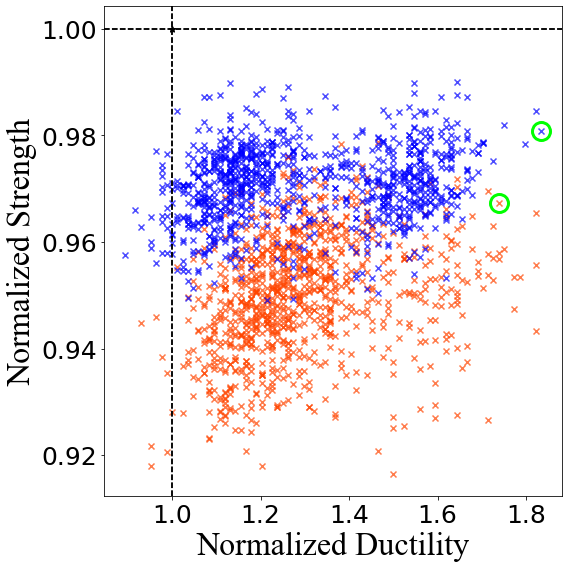

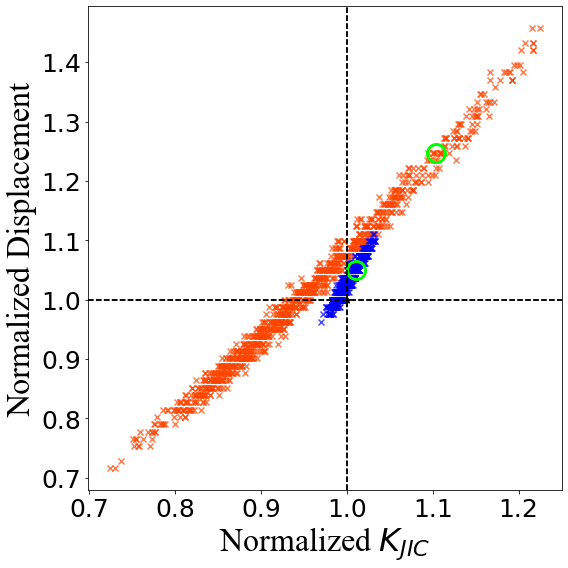

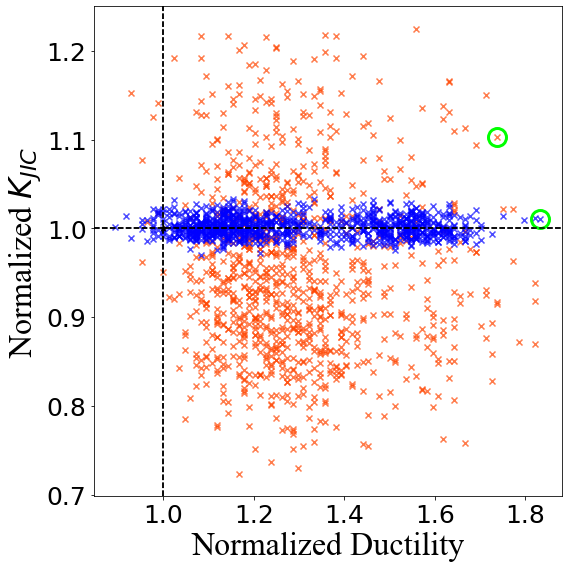

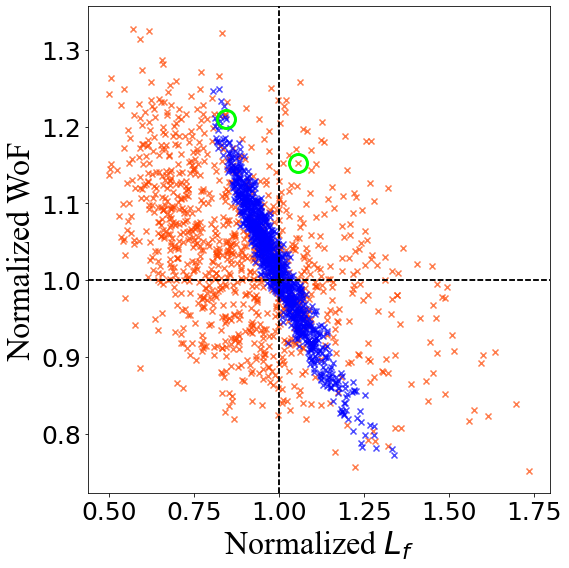

In [11]:
plot_allProps = True
plot_freq = False
plot_ONLY_freq = False

if plot_allProps:
    if DAT.UTmechTest:  
        fig, ax = plot_properties(DAT.UT_allProps_df["Ductility"], DAT.UT_allProps_df["Strength"], "UT", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]])
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.UT_allProps_df["Ductility"], DATc.UT_allProps_df["Strength"], "UT", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]])
    
    if DAT.FTmechTest:  
        fig, ax = plot_properties(DAT.FT_allProps_df["K_JIC"], DAT.FT_allProps_df["Displacement"], "FT", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]])
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.FT_allProps_df["K_JIC"], DATc.FT_allProps_df["Displacement"], "FT", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]])
   
    if DAT.UTmechTest and DAT.FTmechTest:   
        fig, ax = plot_properties(DAT.common_allProps_df["Ductility"], DAT.common_allProps_df["K_JIC"], "MULTI", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]])
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.common_allProps_df["Ductility"], DATc.common_allProps_df["K_JIC"], "MULTI", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]])
            
        fig, ax = plot_properties(DAT.common_allProps_df["FCL"], DAT.common_allProps_df["WoF"], "FCL", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]])
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.common_allProps_df["FCL"], DATc.common_allProps_df["WoF"], "FCL", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]])

if plot_ONLY_freq and DAT.load is not True:
    if DAT.UTmechTest:
        plot_frequency(DAT.UT_allProps_r_df["Ductility"], DAT.UT_allProps_df["Ductility"], "UT", bins=30)
    if DAT.FTmechTest:
        plot_frequency(DAT.FT_allProps_r_df["K_JIC"], DAT.FT_allProps_df["K_JIC"], "FT", bins=30)
    if DAT.UTmechTest and DAT.FTmechTest:
        plot_frequency(DAT.common_allProps_df["FCL"], DAT.common_allProps_df["FCL"], "FCL", bins=30)

# Plots UT and FT Curves

In [12]:
DATc.UT_nSims["Ductility"].loc["Max"], DATc.common_nSims["Multi"].loc["Max"]

(893, 893)

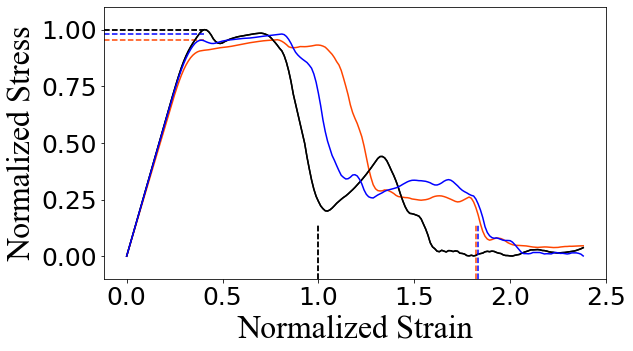

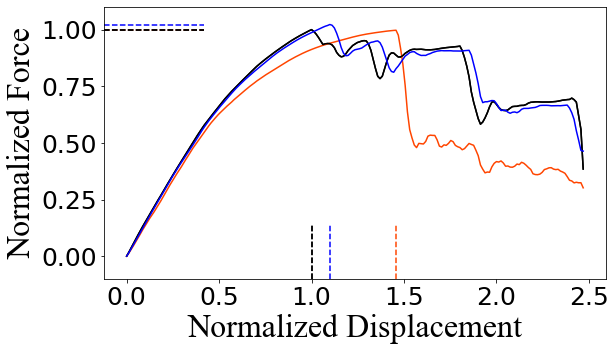

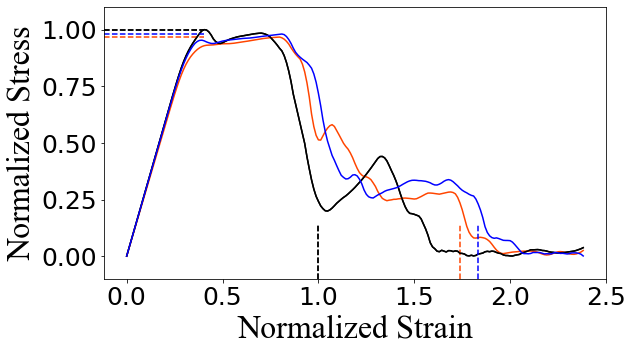

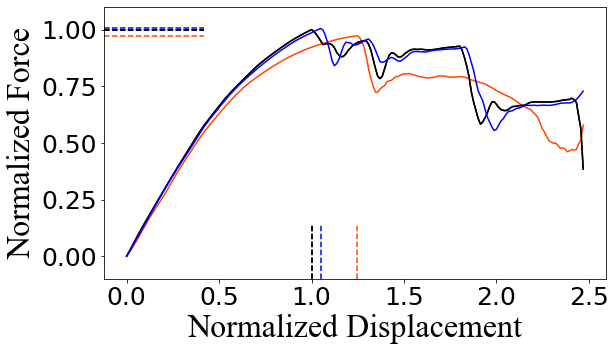

In [13]:
idx = None
q   = "all"
if DAT.UTmechTest:
    fig2, ax1 = plot_curve(DAT.UT_OUT_df, DAT.UT_xOUT, "ut", pi=0, idx=[DAT.UT_nSims["Ductility"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.UT_OUT_df, DATc.UT_xOUT, "ut", pi=0, idx=[DATc.UT_nSims["Ductility"].loc["Max"]], q='all', compare_ax=(fig2, ax1))
    
if DAT.FTmechTest:
    fig2, ax1 = plot_curve(DAT.FT_OUT_df, DAT.FT_xOUT, "ft", pi=0, idx=[DAT.FT_nSims["K_JIC"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.FT_OUT_df, DATc.FT_xOUT, "ft", pi=0, idx=[DATc.FT_nSims["K_JIC"].loc["Max"]], q='all', compare_ax=(fig2, ax1))
    
if DAT.UTmechTest and DAT.FTmechTest:
    fig2, ax1 = plot_curve(DAT.UT_OUT_df, DAT.UT_xOUT, "ut", pi=0, idx=[DAT.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.UT_OUT_df, DATc.UT_xOUT, "ut", pi=0, idx=[DATc.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=(fig2, ax1))
        
    fig2, ax1 = plot_curve(DAT.FT_OUT_df, DAT.FT_xOUT, "ft", pi=0, idx=[DAT.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.FT_OUT_df, DATc.FT_xOUT, "ft", pi=0, idx=[DATc.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=(fig2, ax1))